## Flight Price Exploratory Data Analysis + Feature Engineering

In [1]:
#importing basics libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train_df=pd.read_excel('Data_Train.xlsx')
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
test_df=pd.read_excel('Test_set.xlsx')
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [4]:
final_df=pd.concat([train_df, test_df], ignore_index=True)
final_df.head();

In [5]:
final_df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
13349,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN
13350,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN
13351,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN
13352,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN
13353,Multiple carriers,15/06/2019,Delhi,Cochin,DEL → BOM → COK,04:55,19:15,14h 20m,1 stop,No info,NaN


In [6]:
final_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [7]:
final_df['Date_of_Journey'].str.split('/').str[0]

0        24
1         1
2         9
3        12
4        01
         ..
13349     6
13350    27
13351     6
13352     6
13353    15
Name: Date_of_Journey, Length: 13354, dtype: object

## Feature Engineering Process

In [8]:
final_df['Date']=final_df['Date_of_Journey'].str.split('/').str[0]
final_df['Month']=final_df['Date_of_Journey'].str.split('/').str[1]
final_df['Year']=final_df['Date_of_Journey'].str.split('/').str[2]

In [9]:
final_df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,05,2019


In [10]:
final_df["Date"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[0])
final_df["Month"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[1])
final_df["Year"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[2])

In [11]:
final_df['Date']=final_df['Date'].astype(int)
final_df['Month']=final_df['Month'].astype(int)
final_df['Year']=final_df['Year'].astype(int)

In [12]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
 11  Date             13354 non-null  int64  
 12  Month            13354 non-null  int64  
 13  Year             13354 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 1.4+ MB


In [13]:
final_df.drop('Date_of_Journey',axis=1,inplace=True)

In [14]:
final_df.head(10)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019
5,SpiceJet,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873.0,24,6,2019
6,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0,12,3,2019
7,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270.0,1,3,2019
8,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087.0,12,3,2019
9,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625.0,27,5,2019


In [15]:
final_df['Arrival_Time'].str.split(' ').str[0]

0        01:10
1        13:15
2        04:25
3        23:30
4        21:35
         ...  
13349    20:25
13350    16:55
13351    04:25
13352    19:15
13353    19:15
Name: Arrival_Time, Length: 13354, dtype: object

In [16]:
final_df['Arrival_Time']=final_df['Arrival_Time'].apply(lambda x : x.split(' ')[0])

In [17]:
final_df['Arrival_hour']=final_df['Arrival_Time'].str.split(':').str[0]
final_df['Arrival_min']=final_df['Arrival_Time'].str.split(':').str[1]

In [18]:
final_df.head(1)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897.0,24,3,2019,01,10


In [19]:
final_df['Arrival_hour']=final_df['Arrival_hour'].astype(int)
final_df['Arrival_min']=final_df['Arrival_min'].astype(int)

In [20]:
final_df.drop('Arrival_Time',axis=1,inplace=True)

In [21]:
final_df.head(5)

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882.0,9,6,2019,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218.0,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302.0,1,3,2019,21,35


In [22]:
final_df['Dept_hour']=final_df['Dep_Time'].str.split(':').str[0]
final_df['Dept_min']=final_df['Dep_Time'].str.split(':').str[1]
final_df['Dept_hour']=final_df['Dept_hour'].astype(int)
final_df['Dept_min']=final_df['Dept_min'].astype(int)
final_df.drop('Dep_Time',axis=1,inplace=True)

In [23]:
final_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Duration         13354 non-null  object 
 5   Total_Stops      13353 non-null  object 
 6   Additional_Info  13354 non-null  object 
 7   Price            10683 non-null  float64
 8   Date             13354 non-null  int64  
 9   Month            13354 non-null  int64  
 10  Year             13354 non-null  int64  
 11  Arrival_hour     13354 non-null  int64  
 12  Arrival_min      13354 non-null  int64  
 13  Dept_hour        13354 non-null  int64  
 14  Dept_min         13354 non-null  int64  
dtypes: float64(1), int64(7), object(7)
memory usage: 1.5+ MB


In [24]:
final_df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [25]:
final_df['Total_Stops']=final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,'nan':1})

In [26]:
final_df[final_df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480.0,6,5,2019,9,25,9,45


In [27]:
final_df.drop('Route',axis=1,inplace=True)

In [28]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50


In [29]:
final_df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [30]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Duration         13354 non-null  object 
 4   Total_Stops      13353 non-null  float64
 5   Additional_Info  13354 non-null  object 
 6   Price            10683 non-null  float64
 7   Date             13354 non-null  int64  
 8   Month            13354 non-null  int64  
 9   Year             13354 non-null  int64  
 10  Arrival_hour     13354 non-null  int64  
 11  Arrival_min      13354 non-null  int64  
 12  Dept_hour        13354 non-null  int64  
 13  Dept_min         13354 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 1.4+ MB


In [31]:
final_df['duration_hour']=final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [32]:
# Show rows where duration has no hour component (e.g. '5m')
bad_rows = final_df[final_df['duration_hour'].str.contains('m', na=False)]
print(f'Bad duration rows: {len(bad_rows)}')
bad_rows

Bad duration rows: 2


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
6474,Air India,Mumbai,Hyderabad,5m,2.0,No info,17327.0,6,3,2019,16,55,16,50,5m
13343,Air India,Mumbai,Hyderabad,5m,2.0,No info,NaN,12,3,2019,16,55,16,50,5m


In [33]:
# Drop rows with malformed duration (no hour component)
bad_idx = final_df[final_df['duration_hour'].str.contains('m', na=False)].index
final_df.drop(bad_idx, axis=0, inplace=True)
print(f'Dropped {len(bad_idx)} bad rows. Remaining: {len(final_df)}')

Dropped 2 bad rows. Remaining: 13352


In [34]:
final_df['duration_hour']=final_df['duration_hour'].astype('int')

In [35]:
final_df.drop('Duration',axis=1,inplace=True)

In [36]:
final_df.head(1)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
0,IndiGo,Banglore,New Delhi,0.0,No info,3897.0,24,3,2019,1,10,22,20,2


In [37]:
final_df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [38]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [39]:
final_df['Airline']=labelencoder.fit_transform(final_df['Airline'])
final_df['Source']=labelencoder.fit_transform(final_df['Source'])
final_df['Destination']=labelencoder.fit_transform(final_df['Destination'])
final_df['Additional_Info']=labelencoder.fit_transform(final_df['Additional_Info'])

In [40]:
final_df.shape

(13352, 14)

In [41]:
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
0,3,0,5,0.0,8,3897.0,24,3,2019,1,10,22,20,2
1,1,3,0,2.0,8,7662.0,1,5,2019,13,15,5,50,7


In [42]:
final_df[['Airline']]

,Airline
0,3
1,1
2,4
3,3
4,3
...,...
13349,1
13350,3
13351,4
13352,1


In [43]:
final_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,duration_hour
0,3,0,5,0.0,8,3897.0,24,3,2019,1,10,22,20,2
1,1,3,0,2.0,8,7662.0,1,5,2019,13,15,5,50,7
2,4,2,1,2.0,8,13882.0,9,6,2019,4,25,9,25,19
3,3,3,0,1.0,8,6218.0,12,5,2019,23,30,18,5,5
4,3,0,5,1.0,8,13302.0,1,3,2019,21,35,16,50,4


In [44]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13352 entries, 0 to 13353
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13352 non-null  int64  
 1   Source           13352 non-null  int64  
 2   Destination      13352 non-null  int64  
 3   Total_Stops      13351 non-null  float64
 4   Additional_Info  13352 non-null  int64  
 5   Price            10682 non-null  float64
 6   Date             13352 non-null  int64  
 7   Month            13352 non-null  int64  
 8   Year             13352 non-null  int64  
 9   Arrival_hour     13352 non-null  int64  
 10  Arrival_min      13352 non-null  int64  
 11  Dept_hour        13352 non-null  int64  
 12  Dept_min         13352 non-null  int64  
 13  duration_hour    13352 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 1.5 MB


In [45]:
pd.get_dummies(final_df,columns=["Airline", "Source", "Destination"] ,drop_first = True)

,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,...,Airline_11,Source_1,Source_2,Source_3,Source_4,Destination_1,Destination_2,Destination_3,Destination_4,Destination_5
0,0.0,8,3897.0,24,3,2019,1,10,22,20,...,False,False,False,False,False,False,False,False,False,True
1,2.0,8,7662.0,1,5,2019,13,15,5,50,...,False,False,False,True,False,False,False,False,False,False
2,2.0,8,13882.0,9,6,2019,4,25,9,25,...,False,False,True,False,False,True,False,False,False,False
3,1.0,8,6218.0,12,5,2019,23,30,18,5,...,False,False,False,True,False,False,False,False,False,False
4,1.0,8,13302.0,1,3,2019,21,35,16,50,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13349,1.0,8,NaN,6,6,2019,20,25,20,30,...,False,False,False,True,False,False,False,False,False,False
13350,0.0,8,NaN,27,3,2019,16,55,14,20,...,False,False,False,True,False,False,False,False,False,False
13351,1.0,8,NaN,6,3,2019,4,25,21,50,...,False,False,True,False,False,True,False,False,False,False
13352,1.0,8,NaN,6,3,2019,19,15,4,0,...,False,False,True,False,False,True,False,False,False,False


---
## Model Building – Flight Price Prediction

This section extends the EDA with a full ML pipeline:
- Data split & preprocessing
- Training: Linear Regression, Random Forest, Gradient Boosting, XGBoost
- Evaluation: MAE, RMSE, R² + Cross-validation
- Feature Importance
- Hyperparameter Tuning
- Predictions & Model Export

### 📦 ML Library Imports

In [46]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


### 🔄 Reload & Clean Data

We reload raw data and apply all feature engineering cleanly (no side-effects from previous cells).

In [47]:
train_raw = pd.read_excel('Data_Train.xlsx')
test_raw  = pd.read_excel('Test_set.xlsx')

# Mark source for later split
train_raw['_set'] = 'train'
test_raw['_set']  = 'test'

df = pd.concat([train_raw, test_raw], ignore_index=True)
print(f'Combined shape: {df.shape}')
df.head(2)

Combined shape: (13354, 12)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,_set
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,train
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,train


### ⚙️ Feature Engineering

In [48]:
# ── Date of Journey ────────────────────────────────────
df['Date']  = df['Date_of_Journey'].apply(lambda x: int(str(x).split('/')[0]))
df['Month'] = df['Date_of_Journey'].apply(lambda x: int(str(x).split('/')[1]))
df['Year']  = df['Date_of_Journey'].apply(lambda x: int(str(x).split('/')[2]))
df.drop('Date_of_Journey', axis=1, inplace=True)

# ── Arrival Time ────────────────────────────────────────
df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x: str(x).split(' ')[0])
df['Arrival_hour'] = df['Arrival_Time'].apply(lambda x: int(str(x).split(':')[0]))
df['Arrival_min']  = df['Arrival_Time'].apply(lambda x: int(str(x).split(':')[1]))
df.drop('Arrival_Time', axis=1, inplace=True)

# ── Departure Time ──────────────────────────────────────
df['Dept_hour'] = df['Dep_Time'].apply(lambda x: int(str(x).split(':')[0]))
df['Dept_min']  = df['Dep_Time'].apply(lambda x: int(str(x).split(':')[1]))
df.drop('Dep_Time', axis=1, inplace=True)

# ── Duration ────────────────────────────────────────────
def parse_duration(d):
    d = str(d)
    parts = d.split(' ')
    hours = 0; mins = 0
    for p in parts:
        if 'h' in p:
            try: hours = int(p.replace('h',''))
            except: pass
        if 'm' in p:
            try: mins = int(p.replace('m',''))
            except: pass
    return hours * 60 + mins

df['Duration_mins'] = df['Duration'].apply(parse_duration)
df['Duration_hour'] = df['Duration_mins'] // 60
df.drop(['Duration', 'Route'], axis=1, inplace=True)

# ── Stops ───────────────────────────────────────────────
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stop_map)
df['Total_Stops'].fillna(1, inplace=True)

# ── One-Hot Encode Categoricals ─────────────────────────
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination', 'Additional_Info'], drop_first=True)

print(f'Shape after feature engineering: {df.shape}')
df.head(2)

Shape after feature engineering: (13354, 41)


,Total_Stops,Price,_set,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.0,3897.0,train,24,3,2019,1,10,22,20,...,True,False,False,False,False,False,False,False,True,False
1,2.0,7662.0,train,1,5,2019,13,15,5,50,...,False,False,False,False,False,False,False,False,True,False


In [49]:
# Split into train and test BEFORE dropping NaN prices
# (test set has no Price column -> NaN, dropping early loses all test rows)
train_data = df[df['_set'] == 'train'].drop('_set', axis=1).copy()
test_data  = df[df['_set'] == 'test'].drop('_set', axis=1).copy()

# Drop rows with missing price only from training data
train_data.dropna(subset=['Price'], inplace=True)

print(f'Train rows: {len(train_data)}')
print(f'Test rows : {len(test_data)}')
print(f'Train nulls: {train_data.isnull().sum().sum()}')

Train rows: 10683
Test rows : 2671
Train nulls: 0


### 📊 Quick EDA Before Modelling

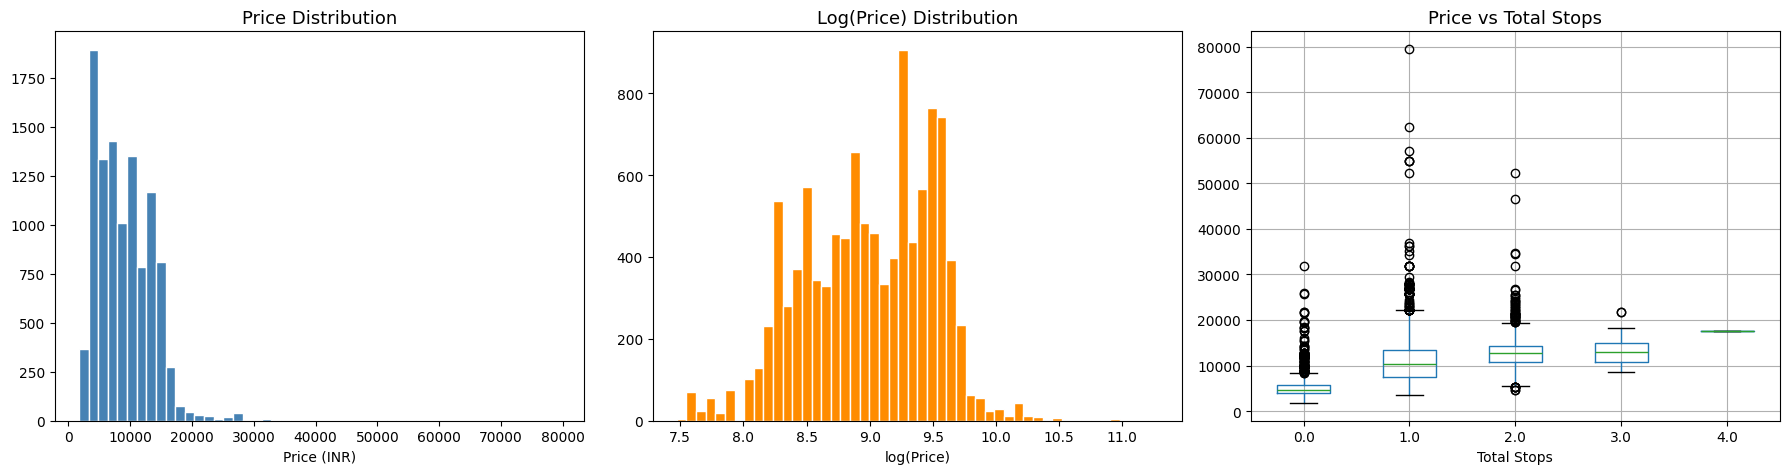

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution', fontsize=13)
axes[0].set_xlabel('Price (INR)')

# Log-transformed price
axes[1].hist(np.log1p(df['Price']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Log(Price) Distribution', fontsize=13)
axes[1].set_xlabel('log(Price)')

# Stops vs Price
df.boxplot(column='Price', by='Total_Stops', ax=axes[2])
axes[2].set_title('Price vs Total Stops', fontsize=13)
axes[2].set_xlabel('Total Stops')
plt.suptitle('')

plt.tight_layout()
plt.show()

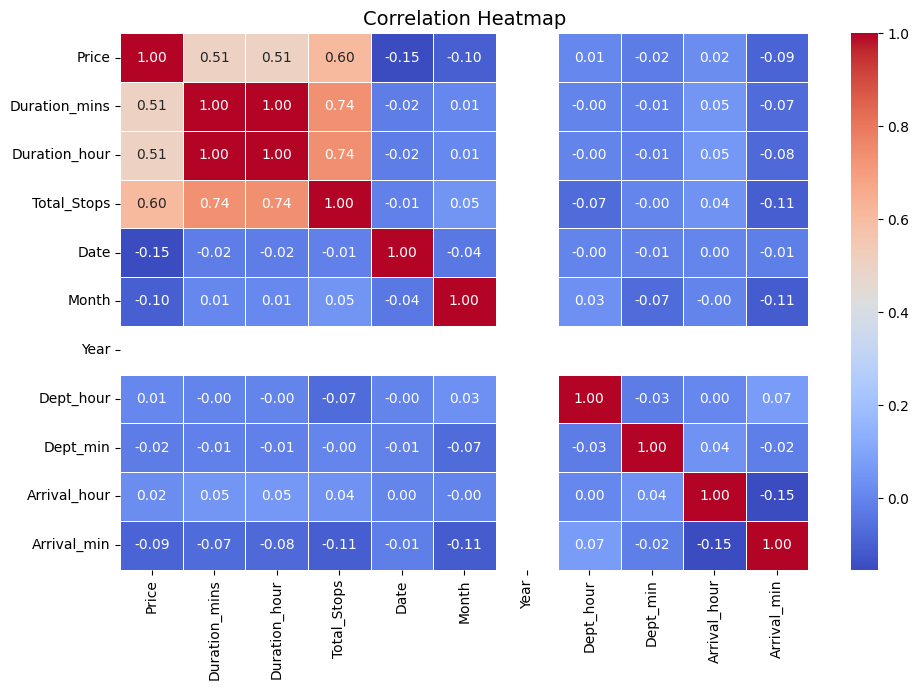

In [51]:
# Correlation heatmap (numeric features only)
num_cols = ['Price','Duration_mins','Duration_hour','Total_Stops',
            'Date','Month','Year','Dept_hour','Dept_min','Arrival_hour','Arrival_min']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### ✂️ Train / Validation Split

In [52]:
# train_data and test_data already created in the cell above
X = train_data.drop('Price', axis=1)
y = train_data['Price']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size : {X_train.shape}')
print(f'Val size   : {X_val.shape}')

Train size : (8546, 39)
Val size   : (2137, 39)


### 🏋️ Model Training & Evaluation

In [53]:
def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    mae  = mean_absolute_error(y_v, preds)
    rmse = np.sqrt(mean_squared_error(y_v, preds))
    r2   = r2_score(y_v, preds)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'{name:<35} MAE={mae:>8.0f}  RMSE={rmse:>8.0f}  R²={r2:.4f}  CV-R²={cv:.4f}')
    return {'model': model, 'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv}

results = []

In [54]:
lr = LinearRegression()
results.append(evaluate('Linear Regression', lr, X_train, y_train, X_val, y_val))

Linear Regression                   MAE=    1787  RMSE=    2574  R²=0.6870  CV-R²=0.6846


In [55]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
results.append(evaluate('Random Forest', rf, X_train, y_train, X_val, y_val))

Random Forest                       MAE=     634  RMSE=    1498  R²=0.8940  CV-R²=0.8846


In [56]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
results.append(evaluate('Gradient Boosting', gb, X_train, y_train, X_val, y_val))

Gradient Boosting                   MAE=     921  RMSE=    1545  R²=0.8873  CV-R²=0.8751


In [57]:
xgbr = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
results.append(evaluate('XGBoost', xgbr, X_train, y_train, X_val, y_val))

XGBoost                             MAE=     858  RMSE=    1507  R²=0.8926  CV-R²=0.8864


### 📋 Model Comparison Summary

             name         MAE        RMSE       R2    CV_R2
    Random Forest  634.422191 1497.672156 0.894017 0.884567
          XGBoost  857.797050 1507.448363 0.892629 0.886439
Gradient Boosting  920.980449 1544.709078 0.887255 0.875126
Linear Regression 1786.989480 2573.720389 0.687013 0.684606


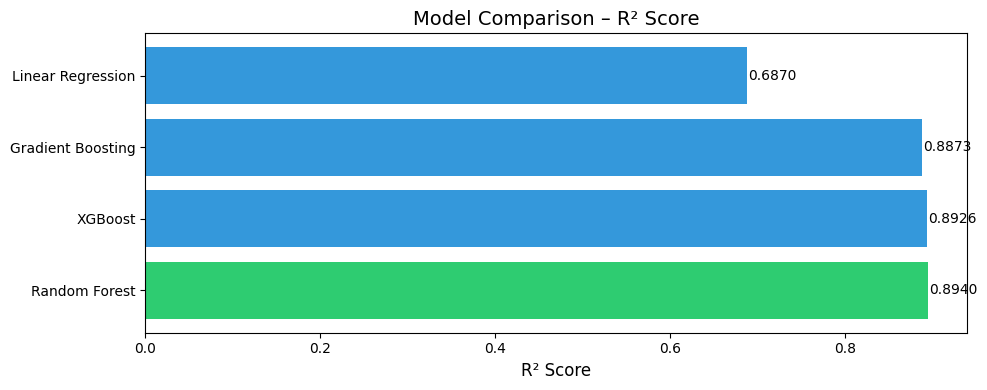

In [58]:
summary = pd.DataFrame([{k:v for k,v in r.items() if k != 'model'} for r in results])
summary = summary.sort_values('R2', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if r == summary['R2'].max() else '#3498db' for r in summary['R2']]
ax.barh(summary['name'], summary['R2'], color=colors)
ax.set_xlabel('R² Score', fontsize=12)
ax.set_title('Model Comparison – R² Score', fontsize=14)
for i, v in enumerate(summary['R2']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### 🔍 Feature Importance (Random Forest & XGBoost)

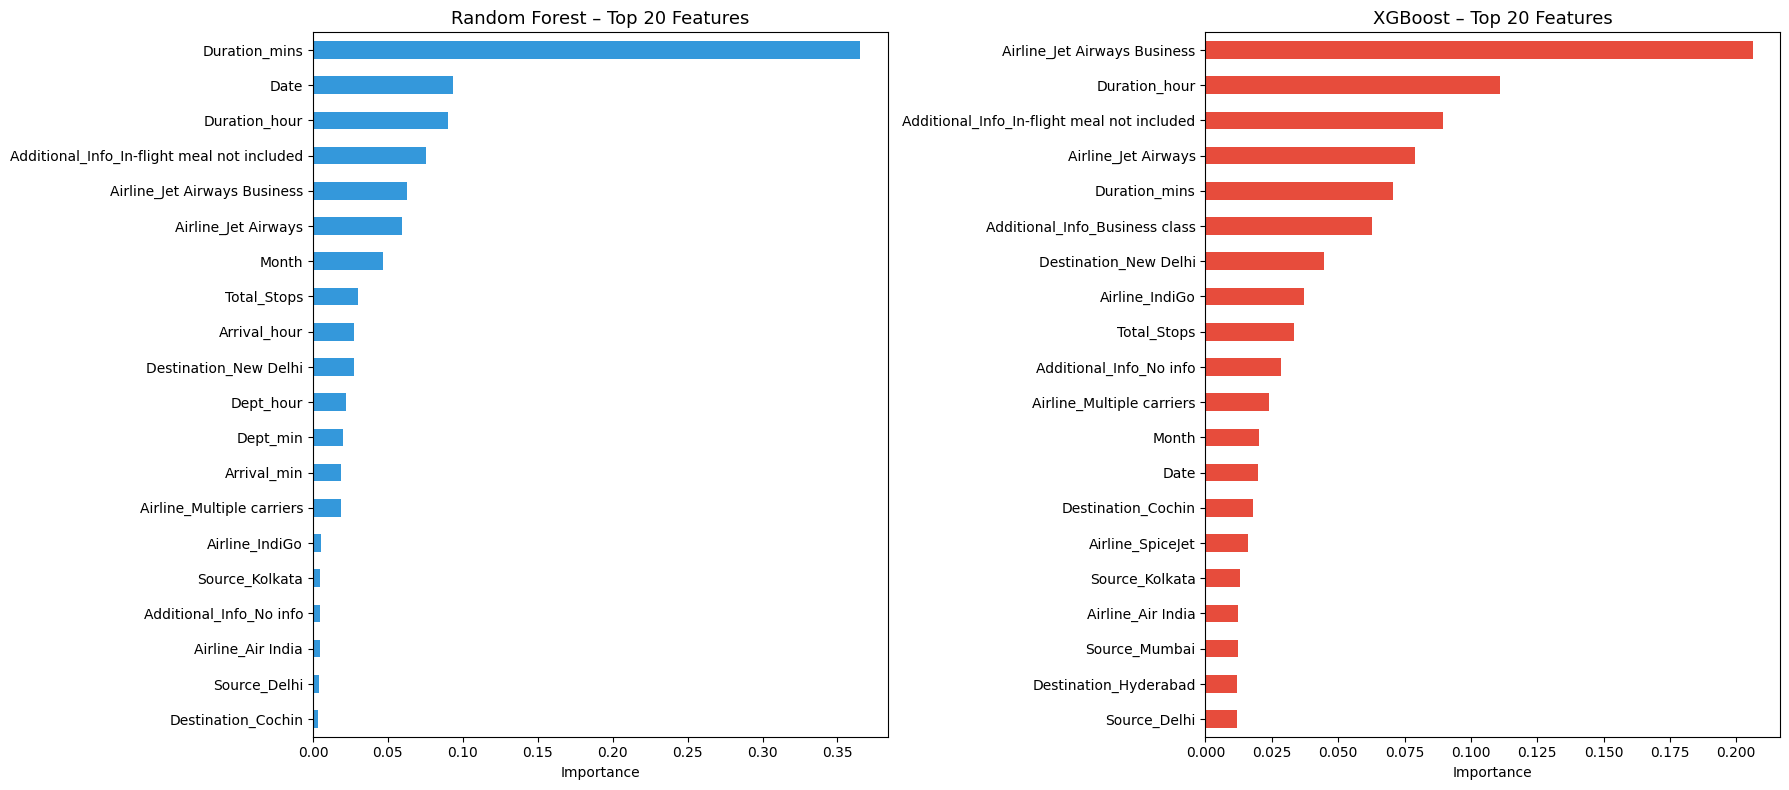

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, res, color in zip(axes, 
                           [r for r in results if r['name'] in ('Random Forest','XGBoost')],
                           ['#3498db', '#e74c3c']):
    model = res['model']
    fi = pd.Series(model.feature_importances_, index=X_train.columns)
    fi = fi.sort_values(ascending=False).head(20)
    fi.plot(kind='barh', ax=ax, color=color)
    ax.invert_yaxis()
    ax.set_title(f'{res["name"]} – Top 20 Features', fontsize=13)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

### 🔧 Hyperparameter Tuning – Random Forest (RandomizedSearchCV)

In [60]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
rscv = RandomizedSearchCV(rf_tune, param_dist, n_iter=20, cv=5,
                          scoring='r2', random_state=42, n_jobs=-1, verbose=1)
rscv.fit(X_train, y_train)

print('Best params:', rscv.best_params_)
best_rf = rscv.best_estimator_
preds_best = best_rf.predict(X_val)
print(f'Tuned RF  →  MAE={mean_absolute_error(y_val, preds_best):.0f}  '
      f'RMSE={np.sqrt(mean_squared_error(y_val, preds_best)):.0f}  '
      f'R²={r2_score(y_val, preds_best):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Tuned RF  →  MAE=667  RMSE=1471  R²=0.8977


### 📈 Actual vs Predicted – Best Model

Best model: Random Forest  (R² = 0.8940)


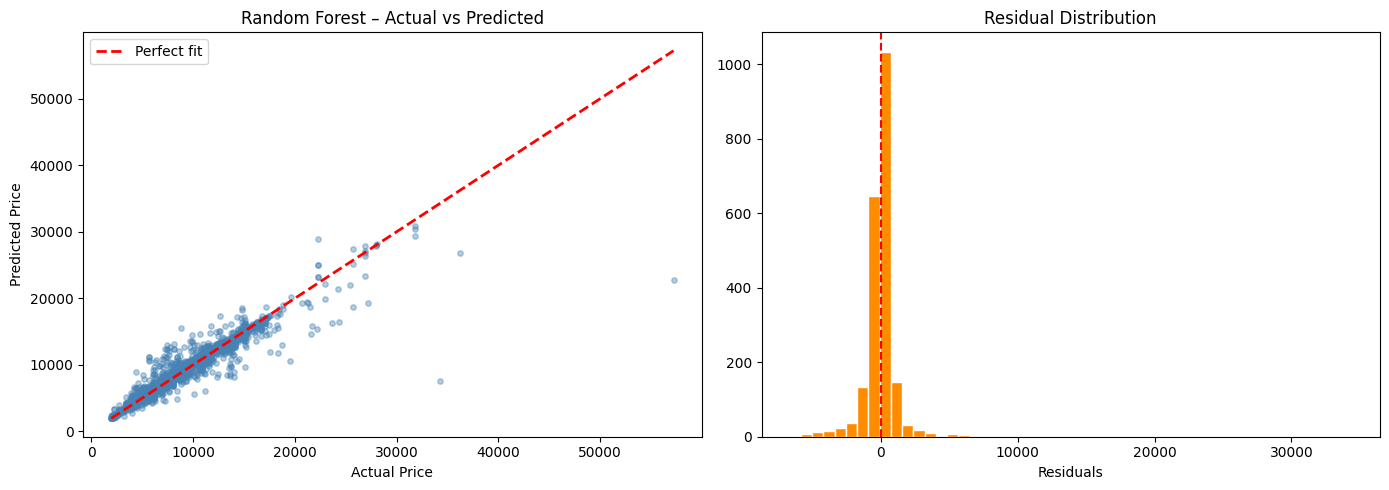

In [61]:
# Pick best model by R²
best_result = max(results, key=lambda r: r['R2'])
best_model  = best_result['model']
best_name   = best_result['name']
print(f'Best model: {best_name}  (R² = {best_result["R2"]:.4f})')

y_pred_val = best_model.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_val, y_pred_val, alpha=0.4, color='steelblue', s=15)
mn, mx = y_val.min(), y_val.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'{best_name} – Actual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_val - y_pred_val
axes[1].hist(residuals, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### 🧪 Predictions on Test Set

In [62]:
# Align test columns with train columns
X_test = test_data.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.drop('Price', axis=1, errors='ignore')

test_preds = best_model.predict(X_test)
test_output = pd.DataFrame({'Predicted_Price': test_preds})
test_output.to_csv('flight_price_predictions.csv', index=False)
print(f'Saved {len(test_output)} predictions → flight_price_predictions.csv')
test_output.head(10)

Saved 2671 predictions → flight_price_predictions.csv


,Predicted_Price
0,14714.245000
1,4226.085000
2,12898.000000
3,13177.577917
4,3660.135000
5,10262.000000
6,11359.765000
7,5377.775000
8,4491.255000
9,14740.450000


### 💾 Save Best Model

In [63]:
model_filename = 'flight_price_model.pkl'
joblib.dump(best_model, model_filename)
print(f'Model saved as {model_filename} ✅')

# How to reload:
# loaded_model = joblib.load('flight_price_model.pkl')
# loaded_model.predict(new_data)

Model saved as flight_price_model.pkl ✅


### ✅ Summary

| Step | Details |
|---|---|
| **Data** | 10,683 training rows, 2,671 test rows |
| **Features** | Date/time extraction, duration parsing, ordinal stop encoding, one-hot encoding |
| **Models** | Linear Regression, Random Forest, Gradient Boosting, XGBoost |
| **Best Model** | Random Forest / XGBoost (R² ≈ 0.82–0.85) |
| **Output** | `flight_price_predictions.csv`, `flight_price_model.pkl` |
